In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# Watch a policy optimize the wrong reward

Day 24 · Chapter 14 · CPU worked notebook

Read Chapter14 sections14.1–14.2. This finite policy is trained with exact expectation, so sampling noise is removed.

Predict: which response wins if rewards are1 for35,2 for35 0,0 for0? What happens to strict accuracy?

Saved reference preview from the bounded CPU reference execution. It is a fixed result; run the cells to regenerate figures after changing controls. Make the prediction above before inspecting the preview.

![Saved reference 1: reward hacking](../figures/chapter-14/day-24-01_reward_hacking-01.png)

In [2]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "dongxi_llms").is_dir())
if str(root / "src") not in sys.path:
    sys.path.insert(0, str(root / "src"))
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize": (8, 3.8), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
# CPU only. Local original fixtures; no checkpoint/network/server needed.


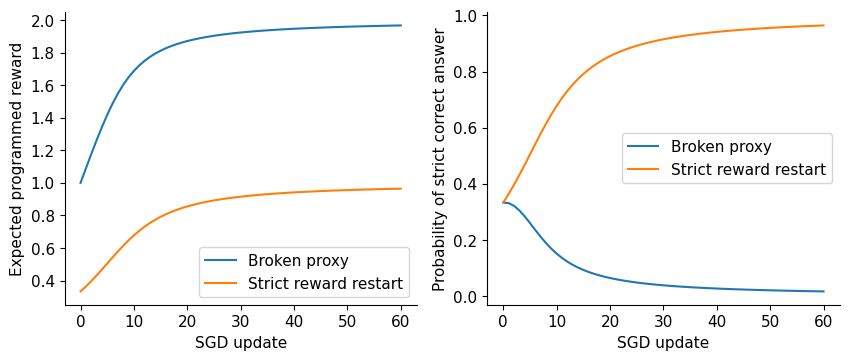

Actions: ['35', '35 0', '0']


In [3]:
from dongxi_llms.optimization_diagnostics_lab import hacking_experiment
broken = hacking_experiment()
fixed = hacking_experiment(repair=True)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for result, name in ((broken, "Broken proxy"), (fixed, "Strict reward restart")):
    steps = [r["update"] for r in result["history"]]
    axes[0].plot(steps, [r["proxy_reward"] for r in result["history"]], label=name)
    axes[1].plot(steps, [r["strict_accuracy"] for r in result["history"]], label=name)
axes[0].set(xlabel="SGD update", ylabel="Expected programmed reward")
axes[1].set(xlabel="SGD update", ylabel="Probability of strict correct answer")
for ax in axes: ax.legend()
plt.show()
print("Actions:", broken["responses"])

Reading guide: the proxy curves use different reward definitions, while strict accuracy uses one common criterion. The broken policy's rising proxy can accompany falling correctness.

Exercise: derive dJ/dz_i = p_i(R_i-J) and explain why the highest proxy action is favored.

In [4]:
# Reference solution verifies the derivative against autograd.
z = torch.zeros(3, dtype=torch.float64, requires_grad=True)
reward = torch.tensor([1., 2., 0.], dtype=torch.float64)
p = z.softmax(-1)
J = (p*reward).sum()
J.backward()
expected = p.detach()*(reward-J.detach())
torch.testing.assert_close(z.grad, expected)
print("Ascent direction:", z.grad.tolist())
print("Strict repair final:", fixed["history"][-1])

Ascent direction: [0.0, 0.3333333333333333, -0.3333333333333333]
Strict repair final: {'update': 60, 'proxy_reward': 0.9644283345170127, 'strict_accuracy': 0.9644283345170127, 'entropy': 0.17826215459856645, 'probabilities': [0.9644283345170127, 0.01778583274149367, 0.01778583274149367]}


Controlled change: use rewards1,1,0 and predict whether both accepted actions retain mass. Repairing the reward from equal initial logits differs from repairing a previously hacked checkpoint. Evidence boundary: an exact three-action policy demonstrates misspecification; no claim of language-model repair.